#Lib

In [ ]:
# 1. Importação de Bibliotecas
import pandas as pd
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from scipy.optimize import linear_sum_assignment # Para a função one_to_one_accuracy
import matplotlib.pyplot as plt

# Nova secção

In [ ]:
# 2. Função de Acurácia (do seu notebook)
def one_to_one_accuracy(annot1, annot2):
    """
    Computes the one-to-one accuracy metric for two lists of annotations.

    Parameters:
    annot1: list of integers, each representing the thread number for the first annotation.
    annot2: list of integers, each representing the thread number for the second annotation.

    Returns:
    accuracy: float, representing the percentage of overlap between the two annotations.
    """
    from scipy.optimize import linear_sum_assignment # Importado novamente para garantir encapsulamento
    import numpy as np # Importado novamente para garantir encapsulamento

    # Create a matrix to store the overlap between thread numbers
    max_thread1 = max(annot1) + 1  # Find the maximum thread number in annot1
    max_thread2 = max(annot2) + 1  # Find the maximum thread number in annot2

    # Initialize a zero matrix for counting overlaps
    overlap_matrix = np.zeros((max_thread1, max_thread2), dtype=int)

    # Fill in the overlap matrix with the count of matching threads
    for a1, a2 in zip(annot1, annot2):
        overlap_matrix[a1, a2] += 1

    # Apply the Hungarian algorithm (linear_sum_assignment) to find the optimal matching
    row_ind, col_ind = linear_sum_assignment(-overlap_matrix) # Usamos -overlap_matrix porque linear_sum_assignment minimiza

    # Calculate total overlap by summing the values at the optimal matching positions
    total_overlap = overlap_matrix[row_ind, col_ind].sum()

    # Calculate one-to-one accuracy as the percentage of overlap found
    accuracy = total_overlap / len(annot1) * 100

    return accuracy


In [ ]:
# 3. Carregamento e Preparação dos Dados
# Assumindo que o arquivo 'AMO_R01.xlsx' está no mesmo diretório ou caminho acessível
try:
    df = pd.read_excel('AMO_R01.xlsx', sheet_name='anotação Bruno')
    turn_text = df["turn_text"].tolist()
    annotation_humana = df["Thread_bruno"].tolist()
    print(f"Dados carregados: {len(turn_text)} turnos e {len(annotation_humana)} anotações.")
except FileNotFoundError:
    print("Erro: Arquivo 'AMO_R01.xlsx' não encontrado. Verifique o caminho.")
    # Saia ou trate o erro como preferir se o arquivo não for encontrado
    exit()




Dados carregados: 236 turnos e 236 anotações.


In [ ]:
# 4. Inicialização do Sentence Transformer
sTransformer1 = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
print("Sentence Transformer 'paraphrase-multilingual-MiniLM-L12-v2' carregado.")



modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer 'paraphrase-multilingual-MiniLM-L12-v2' carregado.


In [ ]:
# 5. Função para Criar o Modelo BERTopic Configurado
def create_topic_model_consolidated(embedding_model_transformer, seed_value, num_clusters=20):
    """
    Cria um modelo BERTopic configurado com os parâmetros especificados.
    """
    umap_model = UMAP(n_neighbors=15,
                      n_components=5,
                      min_dist=0.0,
                      metric='cosine',
                      random_state=seed_value)

    kmeans_model = KMeans(n_clusters=num_clusters,
                          random_state=seed_value,
                          n_init='auto') # n_init='auto' para suprimir warnings futuros do KMeans

    # Não remove stopwords no CountVectorizer, conforme solicitado
    vectorizer_model = CountVectorizer(stop_words=None)

    ctfidf_model = ClassTfidfTransformer()

    topic_model = BERTopic(
        embedding_model=embedding_model_transformer,
        umap_model=umap_model,
        hdbscan_model=kmeans_model, # BERTopic usa hdbscan_model para passar qualquer clusterizador
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        verbose=False
    )
    return topic_model



In [ ]:
# 6. Função para Treinar e Avaliar o Modelo
def train_and_evaluate_model_consolidated(topic_model, documentos, anotacoes_reais):
    """
    Treina o modelo BERTopic e avalia usando a acurácia um-para-um.
    """
    topics, _ = topic_model.fit_transform(documentos)
    # A função one_to_one_accuracy lida com tópicos -1 (outliers) se max() for usado corretamente
    # Se os tópicos atribuídos pelo modelo puderem ter valores negativos (outliers),
    # e a função one_to_one_accuracy não os tratar, pode ser necessário um pré-processamento.
    # No entanto, a função original parece lidar com isso ao calcular max_thread1 = max(annot1) + 1.
    # Se max(topics) for -1, max_thread1 será 0, o que pode causar problemas se annot2 tiver tópicos >=0.
    # Uma solução robusta é mapear os tópicos para garantir que sejam não-negativos ou ajustar a função.
    # Para simplificar, vamos assumir que a sua função one_to_one_accuracy já considera isso
    # ou que os tópicos são maioritariamente não-negativos.
    # Se houver problemas, pode ser necessário remapear os tópicos:
    # topics_normalizados = [t + 1 for t in topics] # Exemplo simples de normalização se -1 for o único outlier
    # accuracy = one_to_one_accuracy(topics_normalizados, anotacoes_reais)

    # Verificação para garantir que todos os tópicos em 'topics' sejam >= 0 para a matriz de sobreposição
    # Se BERTopic retorna -1 para outliers, precisamos ajustar
    min_topic_val = min(topics)
    if min_topic_val < 0:
        # Ajusta os tópicos para serem não-negativos, deslocando todos os valores
        # de forma que o menor valor (ex: -1) se torne 0.
        topics_adjusted = [t - min_topic_val for t in topics]
    else:
        topics_adjusted = topics

    accuracy = one_to_one_accuracy(topics_adjusted, anotacoes_reais)
    return accuracy



In [ ]:
# 7. Loop Principal para Testar 80 Seeds
NUM_TRIALS = 80
accuracy_scores = []
best_accuracy_info = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info = {"accuracy": 101.0, "seed": -1}

print(f"\nIniciando testes com {NUM_TRIALS} seeds diferentes...")

for i in range(NUM_TRIALS):
    current_seed = i # Usando i como seed (0 a 79)
    print(f"--- Testando Seed: {current_seed} ---")

    topic_model_instance = create_topic_model_consolidated(
        embedding_model_transformer=sTransformer1,
        seed_value=current_seed
    )

    current_accuracy = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text,
        annotation_humana
    )
    accuracy_scores.append(current_accuracy)
    print(f"Seed: {current_seed}, Acurácia One-to-One: {current_accuracy:.2f}%")

    if current_accuracy > best_accuracy_info["accuracy"]:
        best_accuracy_info["accuracy"] = current_accuracy
        best_accuracy_info["seed"] = current_seed

    if current_accuracy < worse_accuracy_info["accuracy"]:
        worse_accuracy_info["accuracy"] = current_accuracy
        worse_accuracy_info["seed"] = current_seed

print("\n--- Testes Concluídos ---")




Iniciando testes com 80 seeds diferentes...
--- Testando Seed: 0 ---
Seed: 0, Acurácia One-to-One: 25.85%
--- Testando Seed: 1 ---
Seed: 1, Acurácia One-to-One: 25.00%
--- Testando Seed: 2 ---
Seed: 2, Acurácia One-to-One: 24.58%
--- Testando Seed: 3 ---
Seed: 3, Acurácia One-to-One: 24.58%
--- Testando Seed: 4 ---
Seed: 4, Acurácia One-to-One: 25.00%
--- Testando Seed: 5 ---
Seed: 5, Acurácia One-to-One: 24.15%
--- Testando Seed: 6 ---
Seed: 6, Acurácia One-to-One: 25.00%
--- Testando Seed: 7 ---
Seed: 7, Acurácia One-to-One: 26.27%
--- Testando Seed: 8 ---
Seed: 8, Acurácia One-to-One: 25.00%
--- Testando Seed: 9 ---
Seed: 9, Acurácia One-to-One: 24.15%
--- Testando Seed: 10 ---
Seed: 10, Acurácia One-to-One: 25.85%
--- Testando Seed: 11 ---
Seed: 11, Acurácia One-to-One: 25.42%
--- Testando Seed: 12 ---
Seed: 12, Acurácia One-to-One: 26.27%
--- Testando Seed: 13 ---
Seed: 13, Acurácia One-to-One: 26.27%
--- Testando Seed: 14 ---
Seed: 14, Acurácia One-to-One: 25.42%
--- Testando Se

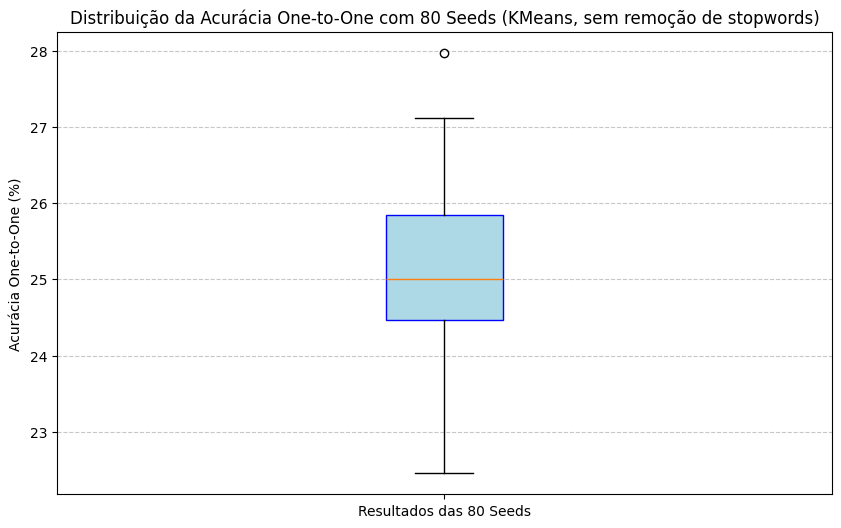


--- Estatísticas dos Resultados ---
Melhor Acurácia: 27.97% (Seed: 68)
Pior Acurácia:   22.46% (Seed: 24)
Acurácia Média:  25.12%
Acurácia Mediana:25.00%
Desvio Padrão:   1.02%


In [ ]:
# 8. Geração do Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(accuracy_scores, patch_artist=True, boxprops=dict(facecolor="lightblue", color="blue"))
plt.title("Distribuição da Acurácia One-to-One com 80 Seeds (KMeans, sem remoção de stopwords)")
plt.ylabel("Acurácia One-to-One (%)")
plt.xticks([1], ['Resultados das 80 Seeds']) # Rótulo para o eixo X
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 9. Exibir Estatísticas Resumidas
if accuracy_scores: # Verifica se a lista não está vazia
    mean_accuracy = np.mean(accuracy_scores)
    median_accuracy = np.median(accuracy_scores)
    std_dev_accuracy = np.std(accuracy_scores)

    print("\n--- Estatísticas dos Resultados ---")
    print(f"Melhor Acurácia: {best_accuracy_info['accuracy']:.2f}% (Seed: {best_accuracy_info['seed']})")
    print(f"Pior Acurácia:   {worse_accuracy_info['accuracy']:.2f}% (Seed: {worse_accuracy_info['seed']})")
    print(f"Acurácia Média:  {mean_accuracy:.2f}%")
    print(f"Acurácia Mediana:{median_accuracy:.2f}%")
    print(f"Desvio Padrão:   {std_dev_accuracy:.2f}%")
else:
    print("Nenhum score de acurácia foi calculado.")

# Sala 3

In [ ]:
# 3. Carregamento e Preparação dos Dados
# Assumindo que o arquivo 'AMO_R01.xlsx' está no mesmo diretório ou caminho acessível
try:
    df = pd.read_excel('AMO_R03.xlsx', sheet_name='anotação Bruno')
    turn_text = df["turn_text"].tolist()
    annotation_humana = df["Thread_bruno"].tolist()
    print(f"Dados carregados: {len(turn_text)} turnos e {len(annotation_humana)} anotações.")
except FileNotFoundError:
    print("Erro: Arquivo 'AMO_R01.xlsx' não encontrado. Verifique o caminho.")
    # Saia ou trate o erro como preferir se o arquivo não for encontrado
    exit()

Dados carregados: 96 turnos e 96 anotações.


In [ ]:
# 7. Loop Principal para Testar 80 Seeds
NUM_TRIALS = 80
accuracy_scores = []
best_accuracy_info = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info = {"accuracy": 101.0, "seed": -1}

print(f"\nIniciando testes com {NUM_TRIALS} seeds diferentes...")

for i in range(NUM_TRIALS):
    current_seed = i # Usando i como seed (0 a 79)
    print(f"--- Testando Seed: {current_seed} ---")

    topic_model_instance = create_topic_model_consolidated(
        embedding_model_transformer=sTransformer1,
        seed_value=current_seed
    )

    current_accuracy = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text,
        annotation_humana
    )
    accuracy_scores.append(current_accuracy)
    print(f"Seed: {current_seed}, Acurácia One-to-One: {current_accuracy:.2f}%")

    if current_accuracy > best_accuracy_info["accuracy"]:
        best_accuracy_info["accuracy"] = current_accuracy
        best_accuracy_info["seed"] = current_seed

    if current_accuracy < worse_accuracy_info["accuracy"]:
        worse_accuracy_info["accuracy"] = current_accuracy
        worse_accuracy_info["seed"] = current_seed

print("\n--- Testes Concluídos ---")




Iniciando testes com 80 seeds diferentes...
--- Testando Seed: 0 ---
Seed: 0, Acurácia One-to-One: 39.58%
--- Testando Seed: 1 ---
Seed: 1, Acurácia One-to-One: 42.71%
--- Testando Seed: 2 ---
Seed: 2, Acurácia One-to-One: 38.54%
--- Testando Seed: 3 ---
Seed: 3, Acurácia One-to-One: 36.46%
--- Testando Seed: 4 ---
Seed: 4, Acurácia One-to-One: 38.54%
--- Testando Seed: 5 ---
Seed: 5, Acurácia One-to-One: 42.71%
--- Testando Seed: 6 ---
Seed: 6, Acurácia One-to-One: 43.75%
--- Testando Seed: 7 ---
Seed: 7, Acurácia One-to-One: 40.62%
--- Testando Seed: 8 ---
Seed: 8, Acurácia One-to-One: 42.71%
--- Testando Seed: 9 ---
Seed: 9, Acurácia One-to-One: 36.46%
--- Testando Seed: 10 ---
Seed: 10, Acurácia One-to-One: 39.58%
--- Testando Seed: 11 ---
Seed: 11, Acurácia One-to-One: 41.67%
--- Testando Seed: 12 ---
Seed: 12, Acurácia One-to-One: 36.46%
--- Testando Seed: 13 ---
Seed: 13, Acurácia One-to-One: 42.71%
--- Testando Seed: 14 ---
Seed: 14, Acurácia One-to-One: 40.62%
--- Testando Se

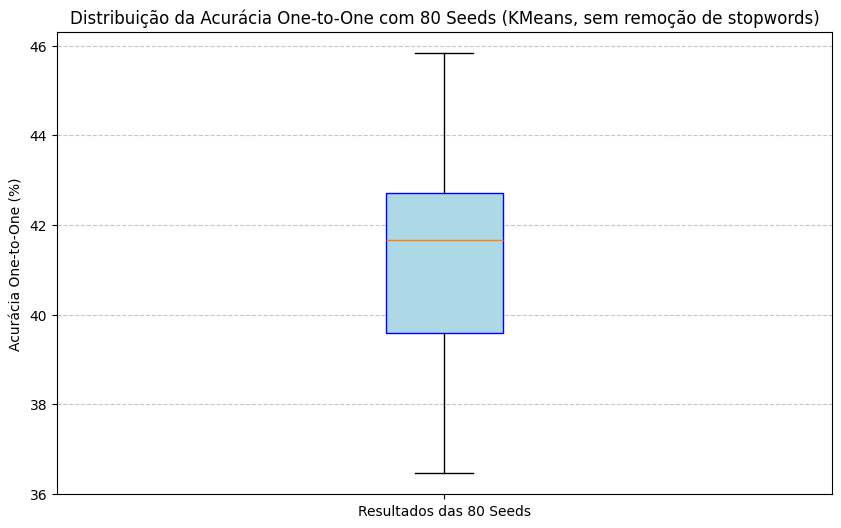


--- Estatísticas dos Resultados ---
Melhor Acurácia: 45.83% (Seed: 44)
Pior Acurácia:   36.46% (Seed: 3)
Acurácia Média:  40.90%
Acurácia Mediana:41.67%
Desvio Padrão:   2.25%


In [ ]:
# 8. Geração do Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(accuracy_scores, patch_artist=True, boxprops=dict(facecolor="lightblue", color="blue"))
plt.title("Distribuição da Acurácia One-to-One com 80 Seeds (KMeans, sem remoção de stopwords)")
plt.ylabel("Acurácia One-to-One (%)")
plt.xticks([1], ['Resultados das 80 Seeds']) # Rótulo para o eixo X
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 9. Exibir Estatísticas Resumidas
if accuracy_scores: # Verifica se a lista não está vazia
    mean_accuracy = np.mean(accuracy_scores)
    median_accuracy = np.median(accuracy_scores)
    std_dev_accuracy = np.std(accuracy_scores)

    print("\n--- Estatísticas dos Resultados ---")
    print(f"Melhor Acurácia: {best_accuracy_info['accuracy']:.2f}% (Seed: {best_accuracy_info['seed']})")
    print(f"Pior Acurácia:   {worse_accuracy_info['accuracy']:.2f}% (Seed: {worse_accuracy_info['seed']})")
    print(f"Acurácia Média:  {mean_accuracy:.2f}%")
    print(f"Acurácia Mediana:{median_accuracy:.2f}%")
    print(f"Desvio Padrão:   {std_dev_accuracy:.2f}%")
else:
    print("Nenhum score de acurácia foi calculado.")

#Sala 7

In [ ]:
# 3. Carregamento e Preparação dos Dados
# Assumindo que o arquivo 'AMO_R01.xlsx' está no mesmo diretório ou caminho acessível
try:
    df = pd.read_excel('AMO_R07.xlsx', sheet_name='anotação Bruno')
    turn_text = df["turn_text"].tolist()
    annotation_humana = df["Thread_bruno"].tolist()
    print(f"Dados carregados: {len(turn_text)} turnos e {len(annotation_humana)} anotações.")
except FileNotFoundError:
    print("Erro: Arquivo 'AMO_R01.xlsx' não encontrado. Verifique o caminho.")
    # Saia ou trate o erro como preferir se o arquivo não for encontrado
    exit()

Dados carregados: 76 turnos e 76 anotações.


In [ ]:
# 7. Loop Principal para Testar 80 Seeds
NUM_TRIALS = 80
accuracy_scores = []
best_accuracy_info = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info = {"accuracy": 101.0, "seed": -1}

print(f"\nIniciando testes com {NUM_TRIALS} seeds diferentes...")

for i in range(NUM_TRIALS):
    current_seed = i # Usando i como seed (0 a 79)
    print(f"--- Testando Seed: {current_seed} ---")

    topic_model_instance = create_topic_model_consolidated(
        embedding_model_transformer=sTransformer1,
        seed_value=current_seed
    )

    current_accuracy = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text,
        annotation_humana
    )
    accuracy_scores.append(current_accuracy)
    print(f"Seed: {current_seed}, Acurácia One-to-One: {current_accuracy:.2f}%")

    if current_accuracy > best_accuracy_info["accuracy"]:
        best_accuracy_info["accuracy"] = current_accuracy
        best_accuracy_info["seed"] = current_seed

    if current_accuracy < worse_accuracy_info["accuracy"]:
        worse_accuracy_info["accuracy"] = current_accuracy
        worse_accuracy_info["seed"] = current_seed

print("\n--- Testes Concluídos ---")




Iniciando testes com 80 seeds diferentes...
--- Testando Seed: 0 ---
Seed: 0, Acurácia One-to-One: 30.26%
--- Testando Seed: 1 ---
Seed: 1, Acurácia One-to-One: 28.95%
--- Testando Seed: 2 ---
Seed: 2, Acurácia One-to-One: 30.26%
--- Testando Seed: 3 ---
Seed: 3, Acurácia One-to-One: 30.26%
--- Testando Seed: 4 ---
Seed: 4, Acurácia One-to-One: 26.32%
--- Testando Seed: 5 ---
Seed: 5, Acurácia One-to-One: 32.89%
--- Testando Seed: 6 ---
Seed: 6, Acurácia One-to-One: 30.26%
--- Testando Seed: 7 ---
Seed: 7, Acurácia One-to-One: 35.53%
--- Testando Seed: 8 ---
Seed: 8, Acurácia One-to-One: 27.63%
--- Testando Seed: 9 ---
Seed: 9, Acurácia One-to-One: 30.26%
--- Testando Seed: 10 ---
Seed: 10, Acurácia One-to-One: 27.63%
--- Testando Seed: 11 ---
Seed: 11, Acurácia One-to-One: 30.26%
--- Testando Seed: 12 ---
Seed: 12, Acurácia One-to-One: 28.95%
--- Testando Seed: 13 ---
Seed: 13, Acurácia One-to-One: 30.26%
--- Testando Seed: 14 ---
Seed: 14, Acurácia One-to-One: 28.95%
--- Testando Se

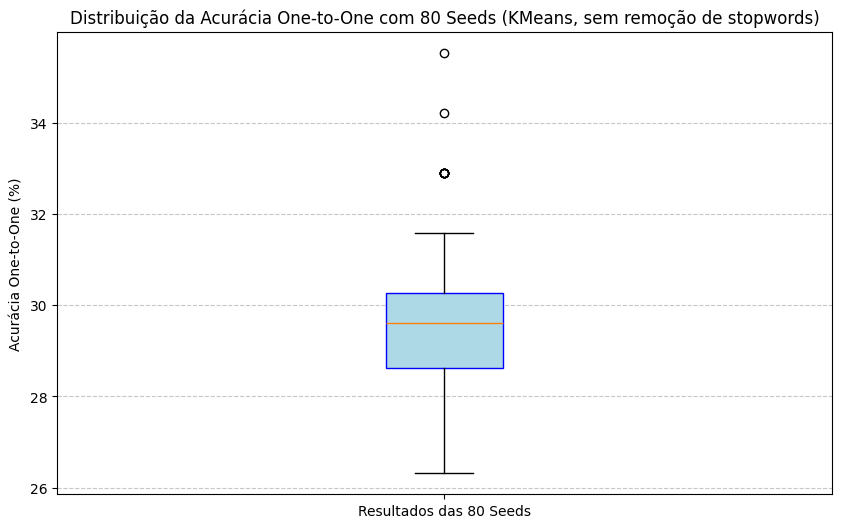


--- Estatísticas dos Resultados ---
Melhor Acurácia: 35.53% (Seed: 7)
Pior Acurácia:   26.32% (Seed: 4)
Acurácia Média:  29.62%
Acurácia Mediana:29.61%
Desvio Padrão:   1.92%


In [ ]:
# 8. Geração do Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(accuracy_scores, patch_artist=True, boxprops=dict(facecolor="lightblue", color="blue"))
plt.title("Distribuição da Acurácia One-to-One com 80 Seeds (KMeans, sem remoção de stopwords)")
plt.ylabel("Acurácia One-to-One (%)")
plt.xticks([1], ['Resultados das 80 Seeds']) # Rótulo para o eixo X
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 9. Exibir Estatísticas Resumidas
if accuracy_scores: # Verifica se a lista não está vazia
    mean_accuracy = np.mean(accuracy_scores)
    median_accuracy = np.median(accuracy_scores)
    std_dev_accuracy = np.std(accuracy_scores)

    print("\n--- Estatísticas dos Resultados ---")
    print(f"Melhor Acurácia: {best_accuracy_info['accuracy']:.2f}% (Seed: {best_accuracy_info['seed']})")
    print(f"Pior Acurácia:   {worse_accuracy_info['accuracy']:.2f}% (Seed: {worse_accuracy_info['seed']})")
    print(f"Acurácia Média:  {mean_accuracy:.2f}%")
    print(f"Acurácia Mediana:{median_accuracy:.2f}%")
    print(f"Desvio Padrão:   {std_dev_accuracy:.2f}%")
else:
    print("Nenhum score de acurácia foi calculado.")

# Sala 9

In [ ]:
# 3. Carregamento e Preparação dos Dados
# Assumindo que o arquivo 'AMO_R01.xlsx' está no mesmo diretório ou caminho acessível
try:
    df = pd.read_excel('AMO_R09.xlsx', sheet_name='anotação Bruno')
    turn_text = df["turn_text"].tolist()
    annotation_humana = df["Thread_bruno"].tolist()
    print(f"Dados carregados: {len(turn_text)} turnos e {len(annotation_humana)} anotações.")
except FileNotFoundError:
    print("Erro: Arquivo 'AMO_R01.xlsx' não encontrado. Verifique o caminho.")
    # Saia ou trate o erro como preferir se o arquivo não for encontrado
    exit()

Dados carregados: 304 turnos e 304 anotações.


In [ ]:
# 7. Loop Principal para Testar 80 Seeds
NUM_TRIALS = 80
accuracy_scores = []
best_accuracy_info = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info = {"accuracy": 101.0, "seed": -1}

print(f"\nIniciando testes com {NUM_TRIALS} seeds diferentes...")

for i in range(NUM_TRIALS):
    current_seed = i # Usando i como seed (0 a 79)
    print(f"--- Testando Seed: {current_seed} ---")

    topic_model_instance = create_topic_model_consolidated(
        embedding_model_transformer=sTransformer1,
        seed_value=current_seed
    )

    current_accuracy = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text,
        annotation_humana
    )
    accuracy_scores.append(current_accuracy)
    print(f"Seed: {current_seed}, Acurácia One-to-One: {current_accuracy:.2f}%")

    if current_accuracy > best_accuracy_info["accuracy"]:
        best_accuracy_info["accuracy"] = current_accuracy
        best_accuracy_info["seed"] = current_seed

    if current_accuracy < worse_accuracy_info["accuracy"]:
        worse_accuracy_info["accuracy"] = current_accuracy
        worse_accuracy_info["seed"] = current_seed

print("\n--- Testes Concluídos ---")




Iniciando testes com 80 seeds diferentes...
--- Testando Seed: 0 ---
Seed: 0, Acurácia One-to-One: 25.00%
--- Testando Seed: 1 ---
Seed: 1, Acurácia One-to-One: 27.30%
--- Testando Seed: 2 ---
Seed: 2, Acurácia One-to-One: 25.99%
--- Testando Seed: 3 ---
Seed: 3, Acurácia One-to-One: 26.64%
--- Testando Seed: 4 ---
Seed: 4, Acurácia One-to-One: 25.99%
--- Testando Seed: 5 ---
Seed: 5, Acurácia One-to-One: 25.00%
--- Testando Seed: 6 ---
Seed: 6, Acurácia One-to-One: 25.99%
--- Testando Seed: 7 ---
Seed: 7, Acurácia One-to-One: 25.33%
--- Testando Seed: 8 ---
Seed: 8, Acurácia One-to-One: 25.99%
--- Testando Seed: 9 ---
Seed: 9, Acurácia One-to-One: 24.67%
--- Testando Seed: 10 ---
Seed: 10, Acurácia One-to-One: 24.01%
--- Testando Seed: 11 ---
Seed: 11, Acurácia One-to-One: 25.66%
--- Testando Seed: 12 ---
Seed: 12, Acurácia One-to-One: 24.34%
--- Testando Seed: 13 ---
Seed: 13, Acurácia One-to-One: 25.66%
--- Testando Seed: 14 ---
Seed: 14, Acurácia One-to-One: 25.33%
--- Testando Se

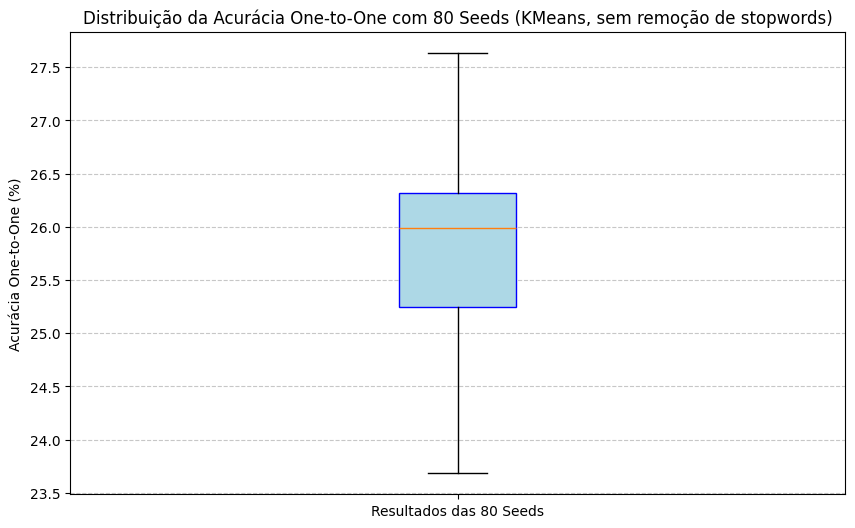


--- Estatísticas dos Resultados ---
Melhor Acurácia: 27.63% (Seed: 37)
Pior Acurácia:   23.68% (Seed: 15)
Acurácia Média:  25.77%
Acurácia Mediana:25.99%
Desvio Padrão:   0.93%


In [ ]:
# 8. Geração do Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(accuracy_scores, patch_artist=True, boxprops=dict(facecolor="lightblue", color="blue"))
plt.title("Distribuição da Acurácia One-to-One com 80 Seeds (KMeans, sem remoção de stopwords)")
plt.ylabel("Acurácia One-to-One (%)")
plt.xticks([1], ['Resultados das 80 Seeds']) # Rótulo para o eixo X
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 9. Exibir Estatísticas Resumidas
if accuracy_scores: # Verifica se a lista não está vazia
    mean_accuracy = np.mean(accuracy_scores)
    median_accuracy = np.median(accuracy_scores)
    std_dev_accuracy = np.std(accuracy_scores)

    print("\n--- Estatísticas dos Resultados ---")
    print(f"Melhor Acurácia: {best_accuracy_info['accuracy']:.2f}% (Seed: {best_accuracy_info['seed']})")
    print(f"Pior Acurácia:   {worse_accuracy_info['accuracy']:.2f}% (Seed: {worse_accuracy_info['seed']})")
    print(f"Acurácia Média:  {mean_accuracy:.2f}%")
    print(f"Acurácia Mediana:{median_accuracy:.2f}%")
    print(f"Desvio Padrão:   {std_dev_accuracy:.2f}%")
else:
    print("Nenhum score de acurácia foi calculado.")

# Todas Salas

In [ ]:
try:
    df = pd.read_excel('AMO_R01.xlsx', sheet_name='anotação Bruno')
    turn_text = df["turn_text"].tolist()
    annotation_humana1 = df["Thread_bruno"].tolist()
    sala1 = len(turn_text)
    print(f"Dados carregados: {len(turn_text)} turnos e {len(annotation_humana1)} anotações.")

    df = pd.read_excel('AMO_R03.xlsx', sheet_name='anotação Bruno')
    turn_text = turn_text + df["turn_text"].tolist()
    annotation_humana3 = df["Thread_bruno"].tolist()
    print(f"Dados carregados: {len(turn_text)} turnos e {len(annotation_humana1) + len(annotation_humana3)} anotações.")

    df = pd.read_excel('AMO_R07.xlsx', sheet_name='anotação Bruno')
    turn_text = turn_text + df["turn_text"].tolist()
    annotation_humana7 = df["Thread_bruno"].tolist()
    print(f"Dados carregados: {len(turn_text)} turnos e {len(annotation_humana1) + len(annotation_humana3) + len(annotation_humana7)} anotações.")

    df = pd.read_excel('AMO_R09.xlsx', sheet_name='anotação Bruno')
    turn_text = turn_text + df["turn_text"].tolist()
    annotation_humana9 = df["Thread_bruno"].tolist()
    print(f"Dados carregados: {len(turn_text)} turnos e {len(annotation_humana1) + len(annotation_humana3) + len(annotation_humana7) + len(annotation_humana9)} anotações.")
except FileNotFoundError:
    print("Erro: Arquivo 'AMO_R01.xlsx' não encontrado. Verifique o caminho.")
    # Saia ou trate o erro como preferir se o arquivo não for encontrado
    exit()

for turn in turn_text:
  print(turn)


Dados carregados: 236 turnos e 236 anotações.
Dados carregados: 332 turnos e 332 anotações.
Dados carregados: 408 turnos e 408 anotações.
Dados carregados: 712 turnos e 712 anotações.
Olá! Sou o moderador. A atividade de hoje vai iniciar às 10h05. Olá! Sou o moderador. A atividade de hoje vai iniciar às 10h05. Olá! Sou o moderador. A atividade de hoje vai iniciar às 10h05.
Ola
Olá!  Sou o moderador. Neste momento os intervenientes estão a entrar na plataforma e a ver o vídeo introdutório do nosso tema de debate de hoje. O debate terá início em 2 minutos.
ola tudo bem
Olá 
Olá!  Sou o moderador. Neste momento os intervenientes estão a entrar na plataforma e a ver o vídeo introdutório do nosso tema de debate de hoje. O debate terá início em 1 minuto. Vamos dar início ao debate. Se tiveres de visualizar o vídeo novamente deves abrir uma nova janela ou separador no teu navegador e ir para o seguinte link: https://www.youtube.com/embed/cki1P3wsJ4A?cc_load_policy=1&cc_lang_pref=pt A pergunta

In [ ]:
R1 = turn_text[0:len(annotation_humana1)]
R3 = turn_text[len(annotation_humana1):len(annotation_humana1 + annotation_humana3)]
R7 = turn_text[len(annotation_humana1 + annotation_humana3):len(annotation_humana1 + annotation_humana3 + annotation_humana7)]
R9 = turn_text[len(annotation_humana1 + annotation_humana3 + annotation_humana7):len(annotation_humana1 + annotation_humana3 + annotation_humana7 + annotation_humana9)]

#print('\n1'.join(R1))
print(f'{len(annotation_humana3)}, {len(annotation_humana1) + len(annotation_humana3) - len(annotation_humana1)}')

96, 96


In [ ]:
def create_topic_model_consolidated(embedding_model_transformer, seed_value, num_clusters=55):
    """
    Cria um modelo BERTopic configurado com os parâmetros especificados.
    """
    umap_model = UMAP(n_neighbors=15,
                      n_components=5,
                      min_dist=0.0,
                      metric='cosine',
                      random_state=seed_value)

    kmeans_model = KMeans(n_clusters=num_clusters,
                          random_state=seed_value,
                          n_init='auto') # n_init='auto' para suprimir warnings futuros do KMeans

    # Não remove stopwords no CountVectorizer, conforme solicitado
    vectorizer_model = CountVectorizer(stop_words=None)

    ctfidf_model = ClassTfidfTransformer()

    topic_model = BERTopic(
        embedding_model=embedding_model_transformer,
        umap_model=umap_model,
        hdbscan_model=kmeans_model, # BERTopic usa hdbscan_model para passar qualquer clusterizador
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        verbose=False
    )
    return topic_model

In [ ]:
def one_to_one_adjusted(topics_adjusted, anotacoes_reais):
  R1 = topics_adjusted[0:len(annotation_humana1)]
  R3 = topics_adjusted[len(annotation_humana1):len(annotation_humana1 + annotation_humana3)]
  R7 = topics_adjusted[len(annotation_humana1 + annotation_humana3):len(annotation_humana1 + annotation_humana3 + annotation_humana7)]
  R9 = topics_adjusted[len(annotation_humana1 + annotation_humana3 + annotation_humana7):len(annotation_humana1 + annotation_humana3 + annotation_humana7 + annotation_humana9)]
  return {
      '1' : one_to_one_accuracy(R1,annotation_humana1),
      '3' : one_to_one_accuracy(R3,annotation_humana1),
      '7' : one_to_one_accuracy(R7,annotation_humana1),
      '9' : one_to_one_accuracy(R9,annotation_humana1)
  }

In [ ]:
def train_and_evaluate_model_consolidated(topic_model, documentos, anotacoes_reais):
    """
    Treina o modelo BERTopic e avalia usando a acurácia um-para-um.
    """
    topics, _ = topic_model.fit_transform(documentos)
    # A função one_to_one_accuracy lida com tópicos -1 (outliers) se max() for usado corretamente
    # Se os tópicos atribuídos pelo modelo puderem ter valores negativos (outliers),
    # e a função one_to_one_accuracy não os tratar, pode ser necessário um pré-processamento.
    # No entanto, a função original parece lidar com isso ao calcular max_thread1 = max(annot1) + 1.
    # Se max(topics) for -1, max_thread1 será 0, o que pode causar problemas se annot2 tiver tópicos >=0.
    # Uma solução robusta é mapear os tópicos para garantir que sejam não-negativos ou ajustar a função.
    # Para simplificar, vamos assumir que a sua função one_to_one_accuracy já considera isso
    # ou que os tópicos são maioritariamente não-negativos.
    # Se houver problemas, pode ser necessário remapear os tópicos:
    # topics_normalizados = [t + 1 for t in topics] # Exemplo simples de normalização se -1 for o único outlier
    # accuracy = one_to_one_accuracy(topics_normalizados, anotacoes_reais)

    # Verificação para garantir que todos os tópicos em 'topics' sejam >= 0 para a matriz de sobreposição
    # Se BERTopic retorna -1 para outliers, precisamos ajustar
    min_topic_val = min(topics)
    if min_topic_val < 0:
        # Ajusta os tópicos para serem não-negativos, deslocando todos os valores
        # de forma que o menor valor (ex: -1) se torne 0.
        topics_adjusted = [t - min_topic_val for t in topics]
    else:
        topics_adjusted = topics

    accuracy = one_to_one_adjusted(topics_adjusted, anotacoes_reais)
    return accuracy, topics_adjusted


In [ ]:
NUM_TRIALS = 500
accuracy_scores = []
best_accuracy_info1 = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info1 = {"accuracy": 101.0, "seed": -1}
best_accuracy_info3 = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info3 = {"accuracy": 101.0, "seed": -1}
best_accuracy_info7 = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info7 = {"accuracy": 101.0, "seed": -1}
best_accuracy_info9 = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info9 = {"accuracy": 101.0, "seed": -1}

best_topics = []

for i in range(NUM_TRIALS):
    current_seed = i # Usando i como seed (0 a 79)
    print(f"--- Testando Seed: {current_seed} ---")

    topic_model_instance = create_topic_model_consolidated(
        embedding_model_transformer=sTransformer1,
        seed_value=current_seed
    )

    current_accuracy, current_topics = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text,
        annotation_humana1 + annotation_humana3 + annotation_humana7 + annotation_humana9
    )
    accuracy_scores.append(current_accuracy)
    print(f"Seed: {current_seed}, Acurácia One-to-One: 1-{current_accuracy['1']:.2f}% 3-{current_accuracy['3']:.2f}% 7-{current_accuracy['7']:.2f}% 9-{current_accuracy['9']:.2f}%")

    if current_accuracy['1'] > best_accuracy_info1["accuracy"]:
        best_accuracy_info1["accuracy"] = current_accuracy['1']
        best_accuracy_info1["seed"] = current_seed

    if current_accuracy['1'] < worse_accuracy_info1["accuracy"]:
        worse_accuracy_info1["accuracy"] = current_accuracy['1']
        worse_accuracy_info1["seed"] = current_seed


    if current_accuracy['3'] > best_accuracy_info3["accuracy"]:
        best_accuracy_info3["accuracy"] = current_accuracy['3']
        best_accuracy_info3["seed"] = current_seed
        best_topics = current_topics

    if current_accuracy['3'] < worse_accuracy_info3["accuracy"]:
        worse_accuracy_info3["accuracy"] = current_accuracy['3']
        worse_accuracy_info3["seed"] = current_seed



    if current_accuracy['7'] > best_accuracy_info7["accuracy"]:
        best_accuracy_info7["accuracy"] = current_accuracy['7']
        best_accuracy_info7["seed"] = current_seed

    if current_accuracy['7'] < worse_accuracy_info7["accuracy"]:
        worse_accuracy_info7["accuracy"] = current_accuracy['7']
        worse_accuracy_info7["seed"] = current_seed


    if current_accuracy['9'] > best_accuracy_info7["accuracy"]:
        best_accuracy_info9["accuracy"] = current_accuracy['9']
        best_accuracy_info9["seed"] = current_seed

    if current_accuracy['9'] < worse_accuracy_info7["accuracy"]:
        worse_accuracy_info9["accuracy"] = current_accuracy['9']
        worse_accuracy_info9["seed"] = current_seed
print("\n--- Testes Concluídos ---")



--- Testando Seed: 0 ---
Seed: 0, Acurácia One-to-One: 1-19.07% 3-20.83% 7-22.37% 9-12.83%
--- Testando Seed: 1 ---
Seed: 1, Acurácia One-to-One: 1-19.92% 3-20.83% 7-21.05% 9-12.83%
--- Testando Seed: 2 ---
Seed: 2, Acurácia One-to-One: 1-19.07% 3-20.83% 7-23.68% 9-12.50%
--- Testando Seed: 3 ---
Seed: 3, Acurácia One-to-One: 1-20.34% 3-20.83% 7-21.05% 9-12.17%
--- Testando Seed: 4 ---
Seed: 4, Acurácia One-to-One: 1-18.22% 3-20.83% 7-25.00% 9-12.17%
--- Testando Seed: 5 ---
Seed: 5, Acurácia One-to-One: 1-18.22% 3-19.79% 7-21.05% 9-12.83%
--- Testando Seed: 6 ---
Seed: 6, Acurácia One-to-One: 1-19.92% 3-19.79% 7-23.68% 9-12.50%
--- Testando Seed: 7 ---
Seed: 7, Acurácia One-to-One: 1-19.07% 3-20.83% 7-21.05% 9-12.50%
--- Testando Seed: 8 ---
Seed: 8, Acurácia One-to-One: 1-18.64% 3-19.79% 7-19.74% 9-12.17%
--- Testando Seed: 9 ---
Seed: 9, Acurácia One-to-One: 1-18.64% 3-19.79% 7-22.37% 9-12.83%
--- Testando Seed: 10 ---
Seed: 10, Acurácia One-to-One: 1-19.49% 3-18.75% 7-21.05% 9-12.5

<ipython-input-13-b81a1e334829>:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(annotations_list,labels = ['1','3','7','9'])


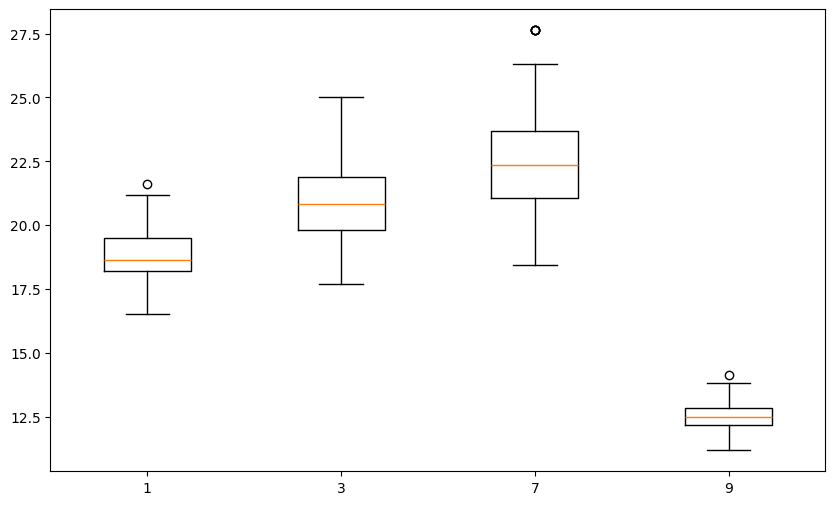

Ann1: 21.610169491525426, Ann3: 25.0, Ann7: 27.631578947368425, Ann9: 14.144736842105262,


In [ ]:
from __future__ import annotations
an1 = []
an3 = []
an7 = []
an9 = []

for val in accuracy_scores:
  an1.append(val['1'])
  an3.append(val['3'])
  an7.append(val['7'])
  an9.append(val['9'])

annotations_list = [an1,an3,an7,an9]

# 8. Geração do Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(annotations_list,labels = ['1','3','7','9'])
plt.show()

print(f"Ann1: {max(an1)}, Ann3: {max(an3)}, Ann7: {max(an7)}, Ann9: {max(an9)},")

# 9. Exibir Estatísticas Resumidas
#if accuracy_scores: # Verifica se a lista não está vazia
    #mean_accuracy = np.mean(accuracy_scores)
    #median_accuracy = np.median(accuracy_scores)
    #std_dev_accuracy = np.std(accuracy_scores)

    #print("\n--- Estatísticas dos Resultados ---")
    #print(f"Melhor Acurácia: {best_accuracy_info['accuracy']:.2f}% (Seed: {best_accuracy_info['seed']})")
    #print(f"Pior Acurácia:   {worse_accuracy_info['accuracy']:.2f}% (Seed: {worse_accuracy_info['seed']})")
    #print(f"Acurácia Média:  {mean_accuracy:.2f}%")
    #print(f"Acurácia Mediana:{median_accuracy:.2f}%")
    #print(f"Desvio Padrão:   {std_dev_accuracy:.2f}%")
#else:
    #print("Nenhum score de acurácia foi calculado.")

# FTest

In [ ]:
def create_topic_model_consolidated(embedding_model_transformer, seed_value, num_clusters=55):
    """
    Cria um modelo BERTopic configurado com os parâmetros especificados.
    """
    umap_model = UMAP(n_neighbors=15,
                      n_components=5,
                      min_dist=0.0,
                      metric='cosine',
                      random_state=seed_value)

    kmeans_model = KMeans(n_clusters=num_clusters,
                          random_state=seed_value,
                          n_init='auto') # n_init='auto' para suprimir warnings futuros do KMeans

    # Não remove stopwords no CountVectorizer, conforme solicitado
    vectorizer_model = CountVectorizer(stop_words=None)

    ctfidf_model = ClassTfidfTransformer()

    topic_model = BERTopic(
        embedding_model=embedding_model_transformer,
        umap_model=umap_model,
        hdbscan_model=kmeans_model, # BERTopic usa hdbscan_model para passar qualquer clusterizador
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        verbose=False
    )
    return topic_model

In [ ]:
# 6. Função para Treinar e Avaliar o Modelo
def train_and_evaluate_model_consolidated(topic_model, documentos, anotacoes_reais):
    """
    Treina o modelo BERTopic e avalia usando a acurácia um-para-um.
    """
    topics, _ = topic_model.fit_transform(documentos)
    # A função one_to_one_accuracy lida com tópicos -1 (outliers) se max() for usado corretamente
    # Se os tópicos atribuídos pelo modelo puderem ter valores negativos (outliers),
    # e a função one_to_one_accuracy não os tratar, pode ser necessário um pré-processamento.
    # No entanto, a função original parece lidar com isso ao calcular max_thread1 = max(annot1) + 1.
    # Se max(topics) for -1, max_thread1 será 0, o que pode causar problemas se annot2 tiver tópicos >=0.
    # Uma solução robusta é mapear os tópicos para garantir que sejam não-negativos ou ajustar a função.
    # Para simplificar, vamos assumir que a sua função one_to_one_accuracy já considera isso
    # ou que os tópicos são maioritariamente não-negativos.
    # Se houver problemas, pode ser necessário remapear os tópicos:
    # topics_normalizados = [t + 1 for t in topics] # Exemplo simples de normalização se -1 for o único outlier
    # accuracy = one_to_one_accuracy(topics_normalizados, anotacoes_reais)

    # Verificação para garantir que todos os tópicos em 'topics' sejam >= 0 para a matriz de sobreposição
    # Se BERTopic retorna -1 para outliers, precisamos ajustar
    min_topic_val = min(topics)
    if min_topic_val < 0:
        # Ajusta os tópicos para serem não-negativos, deslocando todos os valores
        # de forma que o menor valor (ex: -1) se torne 0.
        topics_adjusted = [t - min_topic_val for t in topics]
    else:
        topics_adjusted = topics

    accuracy = one_to_one_accuracy(topics_adjusted, anotacoes_reais)
    return accuracy , topics_adjusted


In [ ]:
try:
    df = pd.read_excel('AMO_R01.xlsx', sheet_name='anotação Bruno')
    turn_text1 = df["turn_text"].tolist()
    annotation_humana1 = df["Thread_bruno"].tolist()

    df = pd.read_excel('AMO_R03.xlsx', sheet_name='anotação Bruno')
    turn_text3 = df["turn_text"].tolist()
    annotation_humana3 = df["Thread_bruno"].tolist()

    df = pd.read_excel('AMO_R07.xlsx', sheet_name='anotação Bruno')
    turn_text7 = df["turn_text"].tolist()
    annotation_humana7 = df["Thread_bruno"].tolist()

    df = pd.read_excel('AMO_R09.xlsx', sheet_name='anotação Bruno')
    turn_text9 = df["turn_text"].tolist()
    annotation_humana9 = df["Thread_bruno"].tolist()
except FileNotFoundError:
    print("Erro: Arquivo 'AMO_R01.xlsx' não encontrado. Verifique o caminho.")
    # Saia ou trate o erro como preferir se o arquivo não for encontrado
    exit()

In [ ]:
NUM_TRIALS = 500
accuracy_score1 = []
accuracy_score3 = []
accuracy_score7 = []
accuracy_score9 = []
best_accuracy_info1 = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info1 = {"accuracy": 101.0, "seed": -1}
best_accuracy_info3 = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info3 = {"accuracy": 101.0, "seed": -1}
best_accuracy_info7 = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info7 = {"accuracy": 101.0, "seed": -1}
best_accuracy_info9 = {"accuracy": -1.0, "seed": -1}
worse_accuracy_info9 = {"accuracy": 101.0, "seed": -1}

best_topics1 = []
best_topics3 = []
best_topics7 = []
best_topics9 = []

for i in range(NUM_TRIALS):
    current_seed = i # Usando i como seed (0 a 79)
    print(f"--- Testando Seed: {current_seed} ---")

    topic_model_instance = create_topic_model_consolidated(
        embedding_model_transformer=sTransformer1,
        seed_value=current_seed
    )

    current_accuracy1, current_topics1 = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text1,
        annotation_humana1
    )
    accuracy_score1.append(current_accuracy1)

    current_accuracy3,current_topics3 = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text3,
        annotation_humana3
    )
    accuracy_score3.append(current_accuracy3)

    current_accuracy7,current_topics7 = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text7,
        annotation_humana7
    )
    accuracy_score7.append(current_accuracy7)

    current_accuracy9,current_topics9 = train_and_evaluate_model_consolidated(
        topic_model_instance,
        turn_text9,
        annotation_humana9
    )

    accuracy_score9.append(current_accuracy9)
    print(f"Seed: {current_seed}, Acurácia One-to-One: 1-{current_accuracy1:.2f}% 3-{current_accuracy3:.2f}% 7-{current_accuracy7:.2f}% 9-{current_accuracy9:.2f}%")

    if current_accuracy1 > best_accuracy_info1["accuracy"]:
        best_accuracy_info1["accuracy"] = current_accuracy1
        best_accuracy_info1["seed"] = current_seed
        best_topics1 = current_topics1

    if current_accuracy1 < worse_accuracy_info1["accuracy"]:
        worse_accuracy_info1["accuracy"] = current_accuracy1
        worse_accuracy_info1["seed"] = current_seed


    if current_accuracy3 > best_accuracy_info3["accuracy"]:
        best_accuracy_info3["accuracy"] = current_accuracy3
        best_accuracy_info3["seed"] = current_seed
        best_topics3 = current_topics3

    if current_accuracy3 < worse_accuracy_info3["accuracy"]:
        worse_accuracy_info3["accuracy"] = current_accuracy3
        worse_accuracy_info3["seed"] = current_seed



    if current_accuracy7 > best_accuracy_info7["accuracy"]:
        best_accuracy_info7["accuracy"] = current_accuracy7
        best_accuracy_info7["seed"] = current_seed
        best_topics7 = current_topics7

    if current_accuracy7 < worse_accuracy_info7["accuracy"]:
        worse_accuracy_info7["accuracy"] = current_accuracy7
        worse_accuracy_info7["seed"] = current_seed


    if current_accuracy9 > best_accuracy_info7["accuracy"]:
        best_accuracy_info9["accuracy"] = current_accuracy9
        best_accuracy_info9["seed"] = current_seed
        best_topics9 = current_topics9

    if current_accuracy9 < worse_accuracy_info7["accuracy"]:
        worse_accuracy_info9["accuracy"] = current_accuracy9
        worse_accuracy_info9["seed"] = current_seed
print("\n--- Testes Concluídos ---")


--- Testando Seed: 0 ---
Seed: 0, Acurácia One-to-One: 1-19.92% 3-26.04% 7-18.42% 9-26.32%
--- Testando Seed: 1 ---
Seed: 1, Acurácia One-to-One: 1-18.22% 3-25.00% 7-15.79% 9-25.66%
--- Testando Seed: 2 ---
Seed: 2, Acurácia One-to-One: 1-19.49% 3-27.08% 7-17.11% 9-27.63%
--- Testando Seed: 3 ---
Seed: 3, Acurácia One-to-One: 1-19.07% 3-27.08% 7-17.11% 9-25.66%
--- Testando Seed: 4 ---
Seed: 4, Acurácia One-to-One: 1-19.49% 3-26.04% 7-19.74% 9-26.97%
--- Testando Seed: 5 ---
Seed: 5, Acurácia One-to-One: 1-18.22% 3-23.96% 7-15.79% 9-25.33%
--- Testando Seed: 6 ---
Seed: 6, Acurácia One-to-One: 1-19.07% 3-23.96% 7-18.42% 9-25.33%
--- Testando Seed: 7 ---
Seed: 7, Acurácia One-to-One: 1-19.92% 3-27.08% 7-15.79% 9-25.99%
--- Testando Seed: 8 ---
Seed: 8, Acurácia One-to-One: 1-19.49% 3-25.00% 7-15.79% 9-27.30%
--- Testando Seed: 9 ---
Seed: 9, Acurácia One-to-One: 1-18.22% 3-27.08% 7-17.11% 9-25.00%
--- Testando Seed: 10 ---
Seed: 10, Acurácia One-to-One: 1-18.64% 3-26.04% 7-18.42% 9-26.3

<ipython-input-11-5db81517154e>:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(annotations_list,labels = ['1','3','7','9'])


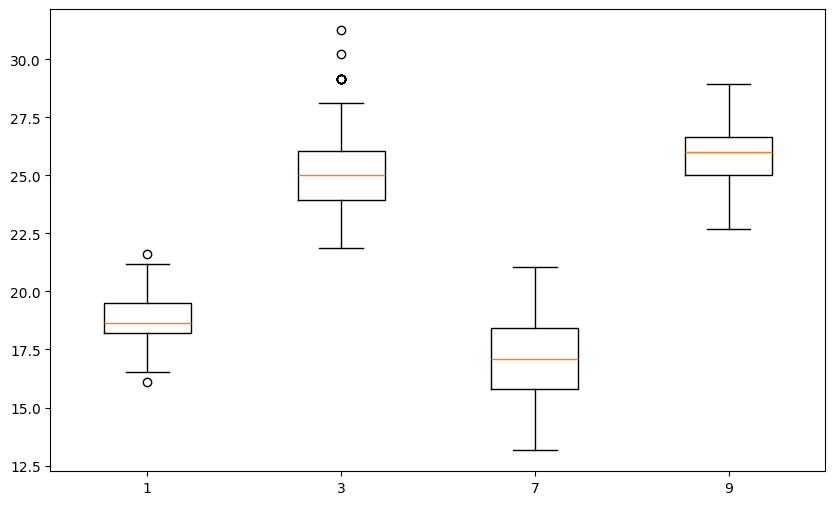

Ann1: 21.610169491525426, Ann3: 31.25, Ann7: 21.052631578947366, Ann9: 28.947368421052634,


In [ ]:
annotations_list = [accuracy_score1,accuracy_score3,accuracy_score7,accuracy_score9]

# 8. Geração do Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(annotations_list,labels = ['1','3','7','9'])
plt.show()

print(f"Ann1: {max(accuracy_score1)}, Ann3: {max(accuracy_score3)}, Ann7: {max(accuracy_score7)}, Ann9: {max(accuracy_score9)},")


In [ ]:
print(f"TOGETHER-{best_topics}")

TOGETHER-[0, 8, 0, 25, 36, 0, 3, 3, 0, 3, 3, 3, 13, 14, 17, 13, 8, 14, 26, 2, 14, 1, 25, 22, 7, 15, 10, 8, 2, 5, 4, 2, 37, 33, 37, 10, 27, 28, 4, 16, 30, 21, 34, 27, 46, 45, 46, 4, 23, 24, 4, 5, 22, 27, 9, 27, 6, 43, 38, 4, 4, 6, 32, 16, 46, 9, 2, 23, 4, 34, 1, 21, 44, 46, 34, 17, 7, 34, 46, 46, 4, 40, 45, 19, 4, 5, 7, 30, 5, 40, 48, 8, 19, 9, 19, 22, 32, 12, 23, 48, 19, 20, 5, 8, 1, 13, 23, 26, 25, 16, 21, 22, 18, 9, 24, 48, 42, 46, 6, 16, 7, 47, 8, 19, 42, 42, 12, 10, 4, 18, 7, 16, 52, 48, 25, 7, 6, 20, 20, 5, 13, 29, 9, 1, 5, 50, 5, 4, 9, 8, 5, 1, 9, 17, 32, 41, 6, 22, 17, 27, 2, 20, 2, 32, 6, 5, 49, 19, 17, 19, 5, 5, 11, 4, 13, 16, 20, 1, 32, 38, 22, 23, 31, 15, 11, 4, 45, 11, 16, 4, 23, 41, 12, 20, 0, 12, 0, 9, 5, 41, 15, 9, 14, 19, 4, 8, 26, 16, 11, 0, 1, 4, 2, 35, 48, 15, 20, 44, 16, 4, 3, 35, 5, 12, 25, 1, 47, 16, 16, 47, 3, 6, 47, 16, 17, 12, 0, 14, 43, 13, 14, 14, 10, 14, 14, 37, 14, 37, 14, 2, 2, 10, 10, 28, 10, 24, 48, 10, 20, 10, 28, 28, 20, 7, 10, 28, 20, 28, 10, 5, 13, 3

In [ ]:
print(f"1-{best_topics1}")

1-[14, 21, 10, 23, 37, 10, 9, 9, 10, 9, 9, 9, 10, 0, 20, 10, 5, 2, 29, 2, 27, 13, 29, 28, 6, 28, 27, 5, 2, 1, 34, 2, 12, 2, 12, 38, 19, 6, 0, 7, 36, 30, 8, 19, 15, 3, 15, 0, 11, 38, 0, 1, 25, 19, 24, 19, 42, 0, 5, 0, 0, 26, 14, 7, 8, 0, 2, 11, 16, 8, 41, 30, 20, 15, 8, 20, 6, 8, 15, 8, 0, 26, 35, 4, 0, 1, 6, 0, 1, 35, 18, 5, 4, 24, 4, 25, 50, 40, 11, 18, 4, 3, 1, 5, 13, 10, 11, 30, 29, 7, 17, 28, 25, 46, 45, 18, 46, 15, 17, 7, 6, 7, 5, 4, 36, 43, 37, 43, 16, 8, 4, 22, 3, 18, 23, 45, 42, 3, 3, 1, 12, 22, 27, 51, 1, 35, 1, 0, 27, 5, 1, 13, 0, 44, 14, 6, 26, 25, 44, 19, 2, 3, 2, 14, 33, 1, 48, 4, 31, 48, 52, 1, 17, 34, 12, 7, 3, 13, 14, 12, 28, 11, 6, 49, 17, 16, 33, 17, 7, 16, 11, 47, 21, 33, 12, 39, 14, 24, 1, 47, 39, 24, 3, 4, 34, 21, 13, 22, 31, 10, 41, 31, 2, 53, 18, 49, 3, 20, 54, 16, 9, 40, 1, 21, 23, 13, 32, 22, 23, 32, 9, 26, 32, 22, 20, 21]


In [ ]:
print(f"3-{best_topics3}")

3-[22, 33, 1, 6, 2, 2, 20, 2, 34, 21, 2, 6, 31, 32, 35, 10, 20, 36, 37, 30, 5, 10, 1, 26, 9, 8, 1, 29, 1, 28, 1, 9, 27, 5, 6, 11, 42, 16, 11, 22, 43, 15, 23, 15, 44, 45, 38, 17, 23, 41, 18, 40, 3, 0, 0, 0, 0, 0, 25, 25, 8, 39, 5, 46, 7, 14, 21, 0, 24, 14, 13, 49, 48, 47, 17, 18, 16, 24, 13, 3, 50, 3, 4, 19, 4, 3, 19, 51, 12, 12, 52, 53, 4, 7, 7, 54]


In [ ]:
print(f"7-{best_topics7}")

7-[2, 0, 0, 0, 2, 0, 2, 14, 21, 12, 0, 13, 6, 6, 5, 5, 17, 9, 22, 1, 4, 16, 15, 7, 8, 18, 19, 20, 24, 3, 23, 7, 26, 8, 25, 30, 10, 27, 28, 4, 10, 29, 31, 32, 34, 33, 35, 36, 1, 37, 1, 11, 11, 38, 39, 40, 41, 42, 43, 44, 3, 45, 9, 46, 47, 48, 1, 49, 3, 50, 51, 52, 1, 53, 54, 2]


In [ ]:
print(f"9-{best_topics9}")

9-[9, 4, 4, 22, 9, 4, 4, 9, 4, 9, 4, 6, 4, 5, 3, 5, 43, 3, 43, 1, 3, 17, 17, 5, 1, 12, 2, 3, 45, 3, 0, 8, 42, 36, 50, 36, 29, 11, 10, 49, 1, 30, 1, 1, 45, 7, 0, 8, 11, 7, 14, 10, 10, 40, 38, 29, 0, 5, 12, 5, 29, 5, 22, 13, 6, 39, 38, 20, 38, 36, 6, 1, 51, 26, 47, 27, 40, 10, 25, 28, 44, 46, 6, 37, 36, 1, 10, 35, 17, 29, 12, 13, 21, 17, 34, 1, 33, 22, 21, 6, 49, 33, 48, 0, 23, 32, 21, 2, 9, 27, 6, 3, 28, 3, 0, 24, 14, 21, 6, 41, 24, 22, 3, 39, 17, 20, 15, 12, 25, 31, 52, 28, 40, 16, 37, 39, 6, 10, 51, 11, 50, 20, 0, 38, 0, 13, 34, 33, 13, 13, 15, 53, 32, 44, 34, 35, 26, 17, 2, 5, 12, 11, 7, 11, 8, 24, 47, 17, 47, 18, 31, 26, 8, 8, 8, 14, 8, 15, 8, 7, 25, 5, 18, 40, 52, 32, 25, 24, 31, 20, 14, 43, 24, 13, 26, 23, 44, 7, 7, 0, 7, 46, 7, 46, 23, 20, 45, 35, 7, 34, 2, 28, 42, 11, 29, 27, 41, 2, 41, 32, 18, 27, 13, 20, 12, 0, 39, 5, 1, 42, 30, 31, 12, 19, 16, 0, 11, 18, 22, 15, 15, 16, 16, 16, 16, 13, 16, 53, 19, 2, 35, 19, 2, 15, 19, 30, 0, 21, 30, 48, 15, 9, 48, 54, 18, 33, 4, 24, 19, 23, 

#BLOCO

In [ ]:
# 1. Função para dividir os turnos em blocos, respeitando o limite de palavras
def split_turns_by_word_limit(turns, max_tokens = 830, prompt_prefix='', prompt_suffix=''):
    """
    Divide a lista de turnos em blocos, cada um com no máximo max_tokens palavras,
    considerando o tamanho do prefixo e sufixo do prompt.
    Turnos que sozinhos excedem o limite são ignorados.
    Retorna uma lista de listas de turnos.
    """
    blocks = []
    current_block = []
    # Conta as palavras do prefixo e sufixo do prompt
    current_tokens = len(prompt_prefix.split()) + len(prompt_suffix.split())
    for turn in turns:
        # Considera o rótulo "Turno N: " + o texto do turno
        turn_label = f"Turno 1: "  # O número não importa para o tamanho
        turn_tokens = len((turn_label + turn).split())
        # Se o turno sozinho já excede o limite, ignora
        if turn_tokens + len(prompt_prefix.split()) + len(prompt_suffix.split()) > max_tokens:
            continue
        # Se adicionar esse turno passa do limite, fecha o bloco e começa outro
        if current_block and (current_tokens + turn_tokens > max_tokens):
            blocks.append(current_block)
            current_block = []
            current_tokens = len(prompt_prefix.split()) + len(prompt_suffix.split())
        # Adiciona o turno ao bloco atual
        current_block.append(turn)
        current_tokens += turn_tokens
    # Adiciona o último bloco, se não estiver vazio
    if current_block:
        blocks.append(current_block)
    return blocks


In [ ]:
def split_turns_balanced(turns, max_tokens = 830, target_block_size = 24, prompt_prefix='', prompt_suffix=''):
    """
    Divide os turnos em blocos de tamanho próximo ao target_block_size,
    sem ultrapassar o limite de tokens.
    O último bloco é ajustado para evitar blocos muito pequenos.
    """
    n = len(turns)
    # Calcula o número ideal de blocos
    n_blocks = max(1, round(n / target_block_size))
    # Calcula o tamanho base de cada bloco
    base_size = n // n_blocks
    remainder = n % n_blocks

    # Gera os índices de corte para os blocos
    block_sizes = [base_size + 1 if i < remainder else base_size for i in range(n_blocks)]
    indices = [0]
    for size in block_sizes:
        indices.append(indices[-1] + size)

    # Agora, para cada bloco, verifica se cabe no limite de tokens
    blocks = []
    for i in range(n_blocks):
        block = turns[indices[i]:indices[i+1]]
        # Se o bloco exceder o limite de tokens, divide em sub-blocos menores
        temp_blocks = split_turns_by_word_limit(
            block, max_tokens, prompt_prefix, prompt_suffix
        )
        blocks.extend(temp_blocks)
    return blocks

In [ ]:
blocks1 = split_turns_balanced(turn_text1)

print('Amo1')
for block in blocks1:
  print(len(block))

blocks3 = split_turns_balanced(turn_text3)

print('Amo3')
for block in blocks3:
  print(len(block))

blocks7 = split_turns_balanced(turn_text7)

print('Amo7')
for block in blocks7:
  print(len(block))

blocks9 = split_turns_balanced(turn_text9)

print('Amo9')
for block in blocks9:
  print(len(block))

Amo1
24
24
24
24
24
24
23
23
23
23
Amo3
16
8
24
24
24
Amo7
26
25
25
Amo9
24
24
24
24
24
23
23
23
23
23
23
23
23


# ONE TO ONE BLOCK

In [ ]:
blocksF = [24,24,24,24,24,24,23,23,23,23,3,18,3,16,8,24,24,9,17,21,4,25,15,9,24,24,24,24,23,23,23,23,23,23,23,23]
len(blocksF)

36

In [ ]:
data = [10, 20, 30, 40, 50, 60, 70, 80]
lengths = [2, 3, 3]  # Split `data` into parts of length 2, 3, and 3

result = []
index = 0

for length in lengths:
    part = data[index:index + length]
    result.append(part)
    index += length

print(result)
# Output: [[10, 20], [30, 40, 50], [60, 70, 80]]


In [ ]:
blocksTOGETHER = [0, 8, 0, 25, 36, 0, 3, 3, 0, 3, 3, 3, 13, 14, 17, 13, 8, 14, 26, 2, 14, 1, 25, 22, 7, 15, 10, 8, 2, 5, 4, 2, 37, 33, 37, 10, 27, 28, 4, 16, 30, 21, 34, 27, 46, 45, 46, 4, 23, 24, 4, 5, 22, 27, 9, 27, 6, 43, 38, 4, 4, 6, 32, 16, 46, 9, 2, 23, 4, 34, 1, 21, 44, 46, 34, 17, 7, 34, 46, 46, 4, 40, 45, 19, 4, 5, 7, 30, 5, 40, 48, 8, 19, 9, 19, 22, 32, 12, 23, 48, 19, 20, 5, 8, 1, 13, 23, 26, 25, 16, 21, 22, 18, 9, 24, 48, 42, 46, 6, 16, 7, 47, 8, 19, 42, 42, 12, 10, 4, 18, 7, 16, 52, 48, 25, 7, 6, 20, 20, 5, 13, 29, 9, 1, 5, 50, 5, 4, 9, 8, 5, 1, 9, 17, 32, 41, 6, 22, 17, 27, 2, 20, 2, 32, 6, 5, 49, 19, 17, 19, 5, 5, 11, 4, 13, 16, 20, 1, 32, 38, 22, 23, 31, 15, 11, 4, 45, 11, 16, 4, 23, 41, 12, 20, 0, 12, 0, 9, 5, 41, 15, 9, 14, 19, 4, 8, 26, 16, 11, 0, 1, 4, 2, 35, 48, 15, 20, 44, 16, 4, 3, 35, 5, 12, 25, 1, 47, 16, 16, 47, 3, 6, 47, 16, 17, 12, 0, 14, 43, 13, 14, 14, 10, 14, 14, 37, 14, 37, 14, 2, 2, 10, 10, 28, 10, 24, 48, 10, 20, 10, 28, 28, 20, 7, 10, 28, 20, 28, 10, 5, 13, 31, 7, 31, 43, 0, 7, 7, 7, 10, 7, 10, 7, 5, 7, 7, 50, 41, 29, 3, 3, 1, 3, 3, 2, 2, 41, 5, 5, 49, 18, 18, 13, 47, 10, 18, 0, 2, 0, 24, 5, 11, 31, 20, 0, 34, 5, 16, 35, 12, 35, 16, 8, 35, 0, 0, 35, 17, 35, 12, 39, 17, 0, 36, 36, 15, 0, 36, 0, 14, 27, 13, 1, 33, 33, 40, 4, 2, 5, 49, 14, 37, 43, 10, 14, 27, 28, 45, 9, 1, 14, 10, 28, 20, 28, 31, 7, 31, 31, 33, 43, 43, 31, 33, 33, 7, 10, 24, 31, 24, 13, 2, 13, 13, 50, 20, 4, 41, 41, 29, 43, 45, 24, 24, 49, 19, 18, 9, 13, 45, 24, 24, 9, 24, 0, 31, 3, 0, 0, 26, 26, 36, 0, 26, 26, 0, 26, 0, 26, 14, 26, 13, 3, 0, 27, 3, 27, 1, 3, 38, 38, 13, 1, 39, 23, 47, 25, 47, 12, 33, 49, 30, 18, 42, 51, 2, 18, 22, 1, 6, 1, 1, 6, 6, 8, 6, 2, 6, 29, 18, 18, 6, 18, 51, 8, 37, 39, 37, 51, 37, 23, 28, 2, 32, 29, 9, 18, 42, 2, 33, 16, 15, 3, 44, 45, 15, 2, 15, 21, 12, 9, 4, 42, 1, 18, 11, 54, 51, 39, 7, 15, 38, 33, 1, 19, 5, 22, 2, 25, 19, 51, 12, 15, 11, 22, 23, 0, 44, 14, 3, 15, 3, 8, 3, 16, 22, 14, 21, 1, 25, 3, 17, 38, 9, 8, 39, 2, 1, 50, 15, 20, 30, 11, 17, 9, 25, 34, 9, 18, 9, 12, 18, 8, 7, 3, 19, 7, 7, 8, 30, 51, 21, 0, 11, 36, 38, 23, 13, 39, 2, 6, 2, 3, 43, 42, 38, 42, 32, 1, 34, 40, 40, 40, 29, 40, 8, 40, 6, 4, 13, 50, 13, 50, 11, 4, 1, 1, 4, 29, 27, 1, 41, 27, 12, 21, 6, 6, 12, 6, 15, 6, 21, 12, 9, 6, 11, 6, 3, 22, 15, 49, 2, 52, 21, 21, 36, 44, 11, 44, 21, 19, 9, 19, 12, 17, 13, 1, 21, 52, 1, 39, 17, 30, 8, 2, 17, 32, 8, 8, 53, 53, 30, 30, 10, 30, 30, 17, 22, 11, 11, 23, 35, 11, 52, 12, 34, 6, 11, 12, 0, 23, 11, 0, 19, 34, 1, 11, 12, 1, 18, 52, 14, 0, 39, 9, 17, 11, 15, 26, 25, 10, 0, 32, 8, 21, 5, 25, 23, 22, 44, 29, 4, 8, 16, 29, 35, 15, 3, 15, 29, 17, 36]
i = 0
blocksT = []

for block in blocksF:
  b = blocksTOGETHER[i:i + block]
  blocksT.append(b)
  i += block

print(len(blocksT[-1]))

#JUNTAR ANOTACAO BRUNO

23


In [ ]:
blocks1 = [14, 21, 10, 23, 37, 10, 9, 9, 10, 9, 9, 9, 10, 0, 20, 10, 5, 2, 29, 2, 27, 13, 29, 28, 6, 28, 27, 5, 2, 1, 34, 2, 12, 2, 12, 38, 19, 6, 0, 7, 36, 30, 8, 19, 15, 3, 15, 0, 11, 38, 0, 1, 25, 19, 24, 19, 42, 0, 5, 0, 0, 26, 14, 7, 8, 0, 2, 11, 16, 8, 41, 30, 20, 15, 8, 20, 6, 8, 15, 8, 0, 26, 35, 4, 0, 1, 6, 0, 1, 35, 18, 5, 4, 24, 4, 25, 50, 40, 11, 18, 4, 3, 1, 5, 13, 10, 11, 30, 29, 7, 17, 28, 25, 46, 45, 18, 46, 15, 17, 7, 6, 7, 5, 4, 36, 43, 37, 43, 16, 8, 4, 22, 3, 18, 23, 45, 42, 3, 3, 1, 12, 22, 27, 51, 1, 35, 1, 0, 27, 5, 1, 13, 0, 44, 14, 6, 26, 25, 44, 19, 2, 3, 2, 14, 33, 1, 48, 4, 31, 48, 52, 1, 17, 34, 12, 7, 3, 13, 14, 12, 28, 11, 6, 49, 17, 16, 33, 17, 7, 16, 11, 47, 21, 33, 12, 39, 14, 24, 1, 47, 39, 24, 3, 4, 34, 21, 13, 22, 31, 10, 41, 31, 2, 53, 18, 49, 3, 20, 54, 16, 9, 40, 1, 21, 23, 13, 32, 22, 23, 32, 9, 26, 32, 22, 20, 21]

In [ ]:
blocks3 = [22, 33, 1, 6, 2, 2, 20, 2, 34, 21, 2, 6, 31, 32, 35, 10, 20, 36, 37, 30, 5, 10, 1, 26, 9, 8, 1, 29, 1, 28, 1, 9, 27, 5, 6, 11, 42, 16, 11, 22, 43, 15, 23, 15, 44, 45, 38, 17, 23, 41, 18, 40, 3, 0, 0, 0, 0, 0, 25, 25, 8, 39, 5, 46, 7, 14, 21, 0, 24, 14, 13, 49, 48, 47, 17, 18, 16, 24, 13, 3, 50, 3, 4, 19, 4, 3, 19, 51, 12, 12, 52, 53, 4, 7, 7, 54]

In [ ]:
blocks7 = [2, 0, 0, 0, 2, 0, 2, 14, 21, 12, 0, 13, 6, 6, 5, 5, 17, 9, 22, 1, 4, 16, 15, 7, 8, 18, 19, 20, 24, 3, 23, 7, 26, 8, 25, 30, 10, 27, 28, 4, 10, 29, 31, 32, 34, 33, 35, 36, 1, 37, 1, 11, 11, 38, 39, 40, 41, 42, 43, 44, 3, 45, 9, 46, 47, 48, 1, 49, 3, 50, 51, 52, 1, 53, 54, 2]

In [ ]:
blocks9 = [9, 4, 4, 22, 9, 4, 4, 9, 4, 9, 4, 6, 4, 5, 3, 5, 43, 3, 43, 1, 3, 17, 17, 5, 1, 12, 2, 3, 45, 3, 0, 8, 42, 36, 50, 36, 29, 11, 10, 49, 1, 30, 1, 1, 45, 7, 0, 8, 11, 7, 14, 10, 10, 40, 38, 29, 0, 5, 12, 5, 29, 5, 22, 13, 6, 39, 38, 20, 38, 36, 6, 1, 51, 26, 47, 27, 40, 10, 25, 28, 44, 46, 6, 37, 36, 1, 10, 35, 17, 29, 12, 13, 21, 17, 34, 1, 33, 22, 21, 6, 49, 33, 48, 0, 23, 32, 21, 2, 9, 27, 6, 3, 28, 3, 0, 24, 14, 21, 6, 41, 24, 22, 3, 39, 17, 20, 15, 12, 25, 31, 52, 28, 40, 16, 37, 39, 6, 10, 51, 11, 50, 20, 0, 38, 0, 13, 34, 33, 13, 13, 15, 53, 32, 44, 34, 35, 26, 17, 2, 5, 12, 11, 7, 11, 8, 24, 47, 17, 47, 18, 31, 26, 8, 8, 8, 14, 8, 15, 8, 7, 25, 5, 18, 40, 52, 32, 25, 24, 31, 20, 14, 43, 24, 13, 26, 23, 44, 7, 7, 0, 7, 46, 7, 46, 23, 20, 45, 35, 7, 34, 2, 28, 42, 11, 29, 27, 41, 2, 41, 32, 18, 27, 13, 20, 12, 0, 39, 5, 1, 42, 30, 31, 12, 19, 16, 0, 11, 18, 22, 15, 15, 16, 16, 16, 16, 13, 16, 53, 19, 2, 35, 19, 2, 15, 19, 30, 0, 21, 30, 48, 15, 9, 48, 54, 18, 33, 4, 24, 19, 23, 1, 19, 30, 37, 9, 12, 6, 18, 54, 28, 4, 26, 11, 9, 37, 0, 27, 14, 2, 2, 21, 10, 14, 25, 15, 10, 14, 22, 23, 3, 23, 14, 18, 2]

In [ ]:
blocks_separated = blocks1 + blocks3 + blocks7 + blocks9
p = 0
blocksS = []

for block in blocksF:
  b = blocks_separated[p:p + block]
  blocksS.append(b)
  p += block

print(len(blocksS))

36


In [ ]:
try:
    df = pd.read_excel('AMO_R01.xlsx', sheet_name='anotação Bruno')
    annotation_humana = df["Thread_bruno"].tolist()

    df = pd.read_excel('AMO_R03.xlsx', sheet_name='anotação Bruno')
    annotation_humana = annotation_humana + df["Thread_bruno"].tolist()

    df = pd.read_excel('AMO_R07.xlsx', sheet_name='anotação Bruno')
    annotation_humana += df["Thread_bruno"].tolist()

    df = pd.read_excel('AMO_R09.xlsx', sheet_name='anotação Bruno')
    annotation_humana += df["Thread_bruno"].tolist()

    df = pd.read_excel('AMO_R01.xlsx', sheet_name='anotação Zuil')
    annotation_humana2 = df["Thread_zuil"].tolist()

    df = pd.read_excel('AMO_R03.xlsx', sheet_name='anotação Zuil')
    annotation_humana2 = annotation_humana2 + df["Thread_zuil"].tolist()

    df = pd.read_excel('AMO_R07.xlsx', sheet_name='anotação Zuil')
    annotation_humana2 = annotation_humana2 + df["Thread_zuil"].tolist()

    df = pd.read_excel('AMO_R09.xlsx', sheet_name='anotação Zuil')
    annotation_humana2 = annotation_humana2 + df["Thread_zuil"].tolist()
except FileNotFoundError:
    print("Erro: Arquivo 'AMO_R01.xlsx' não encontrado. Verifique o caminho.")
    # Saia ou trate o erro como preferir se o arquivo não for encontrado
    exit()

In [ ]:
block_annotation = annotation_humana
a = 0
blocksA = []

for block in blocksF:
  b = block_annotation[a:a + block]
  blocksA.append(b)
  a += block

print(len(blocksA[-1]))

23


In [ ]:
block_annotation = annotation_humana2
a = 0
blocksA2 = []

for block in blocksF:
  b = block_annotation[a:a + block]
  blocksA2.append(b)
  a += block

print(len(blocksA2[-1]))

23


ONE TO ONE CALC HUMANO

In [ ]:
one_to_one_H_results = []

for i in range(0,len(blocksA)):
  one_to_one_H_results.append(one_to_one_accuracy(blocksA[i],blocksA2[i]))

print(len(one_to_one_H_results))
print(one_to_one_H_results)
converted = [float(x) for x in one_to_one_H_results]
print(converted)
print(len(converted))

36
[np.float64(91.66666666666666), np.float64(70.83333333333334), np.float64(45.83333333333333), np.float64(79.16666666666666), np.float64(79.16666666666666), np.float64(62.5), np.float64(73.91304347826086), np.float64(73.91304347826086), np.float64(56.52173913043478), np.float64(100.0), np.float64(100.0), np.float64(94.44444444444444), np.float64(100.0), np.float64(93.75), np.float64(87.5), np.float64(91.66666666666666), np.float64(70.83333333333334), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(80.0), np.float64(100.0), np.float64(100.0), np.float64(95.83333333333334), np.float64(75.0), np.float64(91.66666666666666), np.float64(79.16666666666666), np.float64(60.86956521739131), np.float64(73.91304347826086), np.float64(91.30434782608695), np.float64(82.6086956521739), np.float64(86.95652173913044), np.float64(82.6086956521739), np.float64(73.91304347826086), np.float64(86.95652173913044)]
[91.66666666666666, 70.83333333333334, 45.833333333333

ONE TO ONE CALC TOGETHER

In [ ]:
one_to_one_T_results = []

for i in range(0,len(blocksA)):
  one_to_one_T_results.append(one_to_one_accuracy(blocksA[i],blocksT[i]))

print(len(one_to_one_T_results))
print(one_to_one_T_results)
converted = [float(x) for x in one_to_one_T_results]
print(converted)
print(len(converted))

36
[np.float64(45.83333333333333), np.float64(33.33333333333333), np.float64(16.666666666666664), np.float64(29.166666666666668), np.float64(20.833333333333336), np.float64(33.33333333333333), np.float64(30.434782608695656), np.float64(30.434782608695656), np.float64(43.47826086956522), np.float64(34.78260869565217), np.float64(33.33333333333333), np.float64(72.22222222222221), np.float64(100.0), np.float64(43.75), np.float64(62.5), np.float64(45.83333333333333), np.float64(29.166666666666668), np.float64(44.44444444444444), np.float64(29.411764705882355), np.float64(28.57142857142857), np.float64(100.0), np.float64(32.0), np.float64(80.0), np.float64(44.44444444444444), np.float64(37.5), np.float64(45.83333333333333), np.float64(33.33333333333333), np.float64(37.5), np.float64(30.434782608695656), np.float64(34.78260869565217), np.float64(34.78260869565217), np.float64(34.78260869565217), np.float64(52.17391304347826), np.float64(39.130434782608695), np.float64(56.52173913043478), np.

ONE TO ONE CALC SEPERATED

In [ ]:
one_to_one_S_results = []

for i in range(0,len(blocksA)):
  one_to_one_S_results.append(one_to_one_accuracy(blocksA[i],blocksS[i]))

print(len(one_to_one_S_results))
print(one_to_one_S_results)
converted = [float(x) for x in one_to_one_S_results]
print(converted)
print(len(converted))

36
[np.float64(50.0), np.float64(29.166666666666668), np.float64(25.0), np.float64(29.166666666666668), np.float64(20.833333333333336), np.float64(29.166666666666668), np.float64(30.434782608695656), np.float64(34.78260869565217), np.float64(34.78260869565217), np.float64(30.434782608695656), np.float64(33.33333333333333), np.float64(44.44444444444444), np.float64(66.66666666666666), np.float64(37.5), np.float64(25.0), np.float64(45.83333333333333), np.float64(25.0), np.float64(55.55555555555556), np.float64(23.52941176470588), np.float64(19.047619047619047), np.float64(100.0), np.float64(20.0), np.float64(80.0), np.float64(33.33333333333333), np.float64(33.33333333333333), np.float64(45.83333333333333), np.float64(29.166666666666668), np.float64(33.33333333333333), np.float64(21.73913043478261), np.float64(34.78260869565217), np.float64(30.434782608695656), np.float64(34.78260869565217), np.float64(52.17391304347826), np.float64(52.17391304347826), np.float64(56.52173913043478), np.fl